# Integrated Multi-Threshold Strategy: AI + Graph + Markowitz

Notebook ini menggabungkan:
1. **Enhanced AI Gatekeeper** (Random Forest dengan PCA + Graph Density)
2. **Multi-Threshold Risk Levels** (Standard, Cautious, Conservative, Ultra-Conservative)
3. **Graph Theory (MIS)**: Filter aset berdasarkan korelasi
4. **Markowitz Optimization**: Optimasi portfolio

**Benchmark**: Buy and hold Bitcoin (BTC)

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
import warnings
import os

warnings.filterwarnings('ignore')

# Set style untuk plot
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
sns.set_palette("husl")

## 1. Data Loading & Processing

In [2]:
def load_data(file_path):
    """Load dataset dari file Excel."""
    if os.path.exists(file_path):
        data = pd.read_excel(file_path, index_col=0, parse_dates=True)
        print(f"✅ Loaded {len(data)} rows of data with {len(data.columns)} assets.")
        return data
    else:
        print(f"❌ File data tidak ditemukan: {file_path}")
        return None

def calculate_graph_density_series(ret_df, window=20, threshold=0.5):
    """Calculate rolling graph density based on correlation matrix."""
    print("   Computing Graph Density (topological risk)...")
    rolling_corr = ret_df.rolling(window).corr()
    densities = []
    dates = []
    
    v = len(ret_df.columns)
    max_edges = v * (v - 1) / 2
    
    unique_dates = ret_df.index[window-1:]
    
    for date in unique_dates:
        try:
            corr_matrix = rolling_corr.loc[date]
            corr_matrix = corr_matrix.fillna(0)
            
            adj_matrix = (corr_matrix > threshold).astype(int)
            edges = (adj_matrix.values.sum() - v) / 2
            density = edges / max_edges if max_edges > 0 else 0
            
            densities.append(density)
            dates.append(date)
        except KeyError:
            pass
            
    return pd.Series(densities, index=dates)

def engineer_enhanced_features(data):
    """Enhanced feature engineering with PCA + Graph Density."""
    print("\n📊 Enhanced Feature Engineering...")
    
    # Get crypto assets (exclude stablecoins if needed)
    crypto_assets = [c for c in data.columns if 'PAXG' not in c]
    crypto_data = data[crypto_assets]
    returns = crypto_data.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
    
    print(f"   Processing {len(crypto_assets)} assets...")
    
    # A. PCA Features (Global Market Drivers)
    print("   Applying PCA for dimensionality reduction...")
    scaler = StandardScaler()
    pca = PCA(n_components=5)
    X_features = pd.DataFrame(
        pca.fit_transform(scaler.fit_transform(returns)), 
        index=returns.index, 
        columns=[f'PC{i+1}' for i in range(5)]
    )
    
    # B. BTC-Specific Features (Volatility & Momentum)
    btc_col = 'BTC-USD' if 'BTC-USD' in returns.columns else returns.columns[0]
    print(f"   Using {btc_col} for volatility and momentum features...")
    
    X_features['BTC_Vol_20'] = returns[btc_col].rolling(20).std()
    X_features['BTC_Mom_20'] = returns[btc_col].rolling(20).mean()
    X_features['BTC_Mom_50'] = returns[btc_col].rolling(50).mean()
    
    # C. Graph Density (Topological Risk)
    X_features['Graph_Density'] = calculate_graph_density_series(returns)
    
    # D. Target Construction (Next day return > 0)
    X_features['Target'] = (returns[btc_col].shift(-1) > 0).astype(int)
    
    X_features = X_features.dropna()
    print(f"✅ Feature Matrix Ready. Shape: {X_features.shape}")
    
    return X_features, returns

## 2. AI Model Training (Random Forest)

In [3]:
def train_enhanced_model(features):
    """Train Random Forest with enhanced features."""
    print("\n🤖 Training Enhanced Random Forest Model...")
    
    # Split: Train on 2023-2024, Test on 2025
    train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
    test_mask = (features.index.year == 2025)
    
    if not any(test_mask):
        print("⚠️  Warning: No test data found for 2025. Using last 20% for testing.")
        split_idx = int(len(features) * 0.8)
        X_train = features.iloc[:split_idx].drop(columns=['Target'])
        y_train = features.iloc[:split_idx]['Target']
        X_test = features.iloc[split_idx:].drop(columns=['Target'])
        y_test = features.iloc[split_idx:]['Target']
    else:
        feature_cols = [c for c in features.columns if c != 'Target']
        X_train = features.loc[train_mask, feature_cols]
        y_train = features.loc[train_mask, 'Target']
        X_test = features.loc[test_mask, feature_cols]
        y_test = features.loc[test_mask, 'Target']
    
    # Train model
    rf_model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        random_state=42,
        min_samples_split=10
    )
    rf_model.fit(X_train, y_train)
    
    # Predictions
    test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)
    train_score = accuracy_score(y_train, rf_model.predict(X_train))
    test_score = accuracy_score(y_test, rf_model.predict(X_test))
    
    print(f"   Train Accuracy: {train_score:.2%}")
    print(f"   Test Accuracy: {test_score:.2%}")
    print("✅ Model training complete!")
    
    return rf_model, test_probs, X_test, y_test

## 3. Graph Theory + Markowitz Optimization

In [4]:
def get_mis_assets(returns_window, correlation_threshold=0.5):
    """Filter aset menggunakan Maximum Independent Set (MIS)."""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    
    mis = nx.maximal_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_assets_returns):
    """Optimasi Markowitz untuk maksimalisasi Sharpe Ratio."""
    if len(selected_assets_returns.columns) == 0:
        return {}
    if len(selected_assets_returns.columns) == 1:
        return {selected_assets_returns.columns[0]: 1.0}
    
    mu = selected_assets_returns.mean() * 252
    sigma = selected_assets_returns.cov() * 252
    
    def neg_sharpe_ratio(weights):
        port_return = np.sum(weights * mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_return / port_volatility if port_volatility > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    initial_guess = len(mu) * [1. / len(mu)]
    
    try:
        result = minimize(neg_sharpe_ratio, initial_guess, method='SLSQP', 
                         bounds=bounds, constraints=constraints)
        return dict(zip(selected_assets_returns.columns, result.x))
    except:
        return dict(zip(selected_assets_returns.columns, initial_guess))

## 4. Strategy Execution Engine

In [5]:
def run_threshold_strategy(test_dates, returns, probs, threshold=0.5, 
                          lookback=30, corr_threshold=0.5):
    """Run strategy with specific threshold."""
    current_value = 10000.0
    history = [current_value]
    dates = [test_dates[0]]
    position_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        # AI Gatekeeper with Threshold
        is_bull = probs.loc[date] >= threshold
        
        loc_idx = returns.index.get_loc(date)
        
        if loc_idx < lookback:
            weights = {'CASH': 1.0}
            position = 'CASH'
        else:
            window_returns = returns.iloc[loc_idx-lookback:loc_idx]
            
            if not is_bull:
                # Bearish: Stay in Cash
                weights = {'CASH': 1.0}
                position = 'CASH'
            else:
                # Bullish: Graph Filter + Markowitz
                selected_assets = get_mis_assets(window_returns, corr_threshold)
                if not selected_assets:
                    weights = {'CASH': 1.0}
                    position = 'CASH'
                else:
                    weights = optimize_markowitz(window_returns[selected_assets])
                    position = 'INVESTED'
        
        position_history.append(position)
        
        # Calculate return for next day
        next_date = test_dates[i+1]
        if next_date not in returns.index:
            break
        
        next_day_rets = returns.loc[next_date]
        
        daily_ret = 0
        if 'CASH' in weights:
            daily_ret = 0
        else:
            for asset, w in weights.items():
                if asset in next_day_rets:
                    daily_ret += w * next_day_rets[asset]
        
        current_value *= (1 + daily_ret)
        history.append(current_value)
        dates.append(next_date)
    
    # Calculate time in market
    time_in_market = (pd.Series(position_history) == 'INVESTED').sum() / len(position_history) * 100
    
    return pd.Series(history, index=dates), time_in_market

## 5. Metrics & Analysis

In [6]:
def calculate_metrics(series):
    """Calculate comprehensive performance metrics."""
    returns = series.pct_change().dropna()
    if len(series) <= 1:
        return {}
    
    total_return = (series.iloc[-1] / series.iloc[0] - 1) * 100
    annual_return = ((series.iloc[-1] / series.iloc[0]) ** (252 / len(series)) - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (annual_return / volatility) if volatility > 0 else 0
    max_dd = ((series / series.cummax()) - 1).min() * 100
    
    # Calmar Ratio
    calmar = (annual_return / abs(max_dd)) if max_dd != 0 else 0
    
    # Win Rate
    win_rate = (returns > 0).sum() / len(returns) * 100 if len(returns) > 0 else 0
    
    return {
        'Total Return (%)': total_return,
        'Annual Return (%)': annual_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Calmar Ratio': calmar,
        'Max Drawdown (%)': max_dd,
        'Win Rate (%)': win_rate,
        'Final Value': series.iloc[-1]
    }

def analyze_confusion_matrices(y_test, probs, thresholds):
    """Analyze confusion matrices for different thresholds."""
    print("\n📊 Analyzing Risk-Averse Performance...")
    
    results = []
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (name, thresh) in enumerate(thresholds.items()):
        y_pred = (probs >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        
        # Handle different confusion matrix shapes
        tn, fp, fn, tp = 0, 0, 0, 0
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        elif cm.shape == (1, 1):
            # Only one class predicted/actual
            if y_pred.sum() == 0:  # All predicted 0 (Bearish)
                tn = cm[0, 0]
            else:  # All predicted 1 (Bullish)
                tp = cm[0, 0]
        
        prec = precision_score(y_test, y_pred, zero_division=0)
        
        results.append({
            'Variant': name,
            'Threshold': thresh,
            'Precision': prec,
            'False_Bullish (FP)': fp,
            'True_Bullish (TP)': tp,
            'False_Bearish (FN)': fn,
            'True_Bearish (TN)': tn
        })
        
        # Plot confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', ax=axes[i],
                   xticklabels=['Bearish', 'Bullish'],
                   yticklabels=['Bearish', 'Bullish'])
        axes[i].set_title(f"{name} (T ≥ {thresh})\nPrecision: {prec:.1%}")
        axes[i].set_xlabel('AI Prediction')
        axes[i].set_ylabel('Actual Market')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    print("✅ Confusion matrices saved!")
    
    return pd.DataFrame(results)

## 6. Main Execution Loop

INTEGRATED MULTI-THRESHOLD STRATEGY
AI + Graph Theory + Markowitz Optimization
✅ Loaded 990 rows of data with 25 assets.

📊 Enhanced Feature Engineering...
   Processing 24 assets...
   Applying PCA for dimensionality reduction...
   Using BTC-USD for volatility and momentum features...
   Computing Graph Density (topological risk)...
✅ Feature Matrix Ready. Shape: (941, 10)

🤖 Training Enhanced Random Forest Model...
   Train Accuracy: 98.78%
   Test Accuracy: 51.78%
✅ Model training complete!

📊 Analyzing Risk-Averse Performance...
✅ Confusion matrices saved!

--- AI MODEL RISK ANALYSIS ---
           Variant  Threshold  Precision  False_Bullish (FP)  True_Bullish (TP)  False_Bearish (FN)  True_Bearish (TN)
          Standard       0.50   0.512690                  96                101                  80                 88
          Cautious       0.65   0.531915                  22                 25                 156                162
      Conservative       0.80   0.000000   

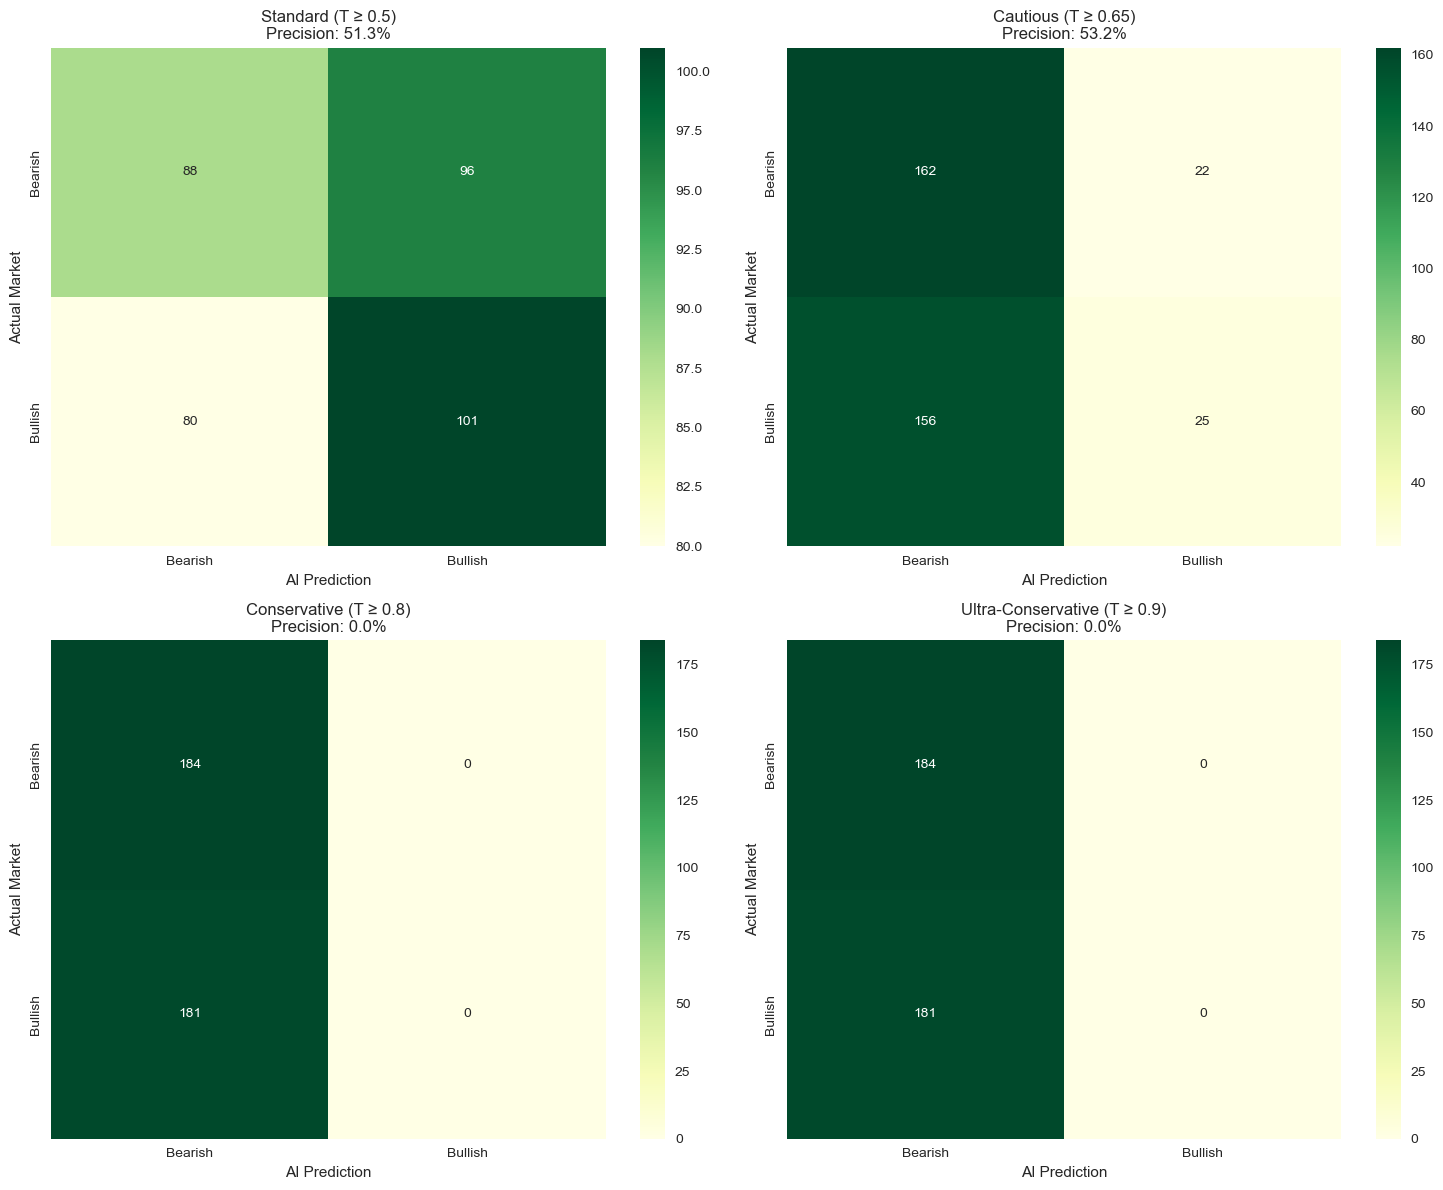

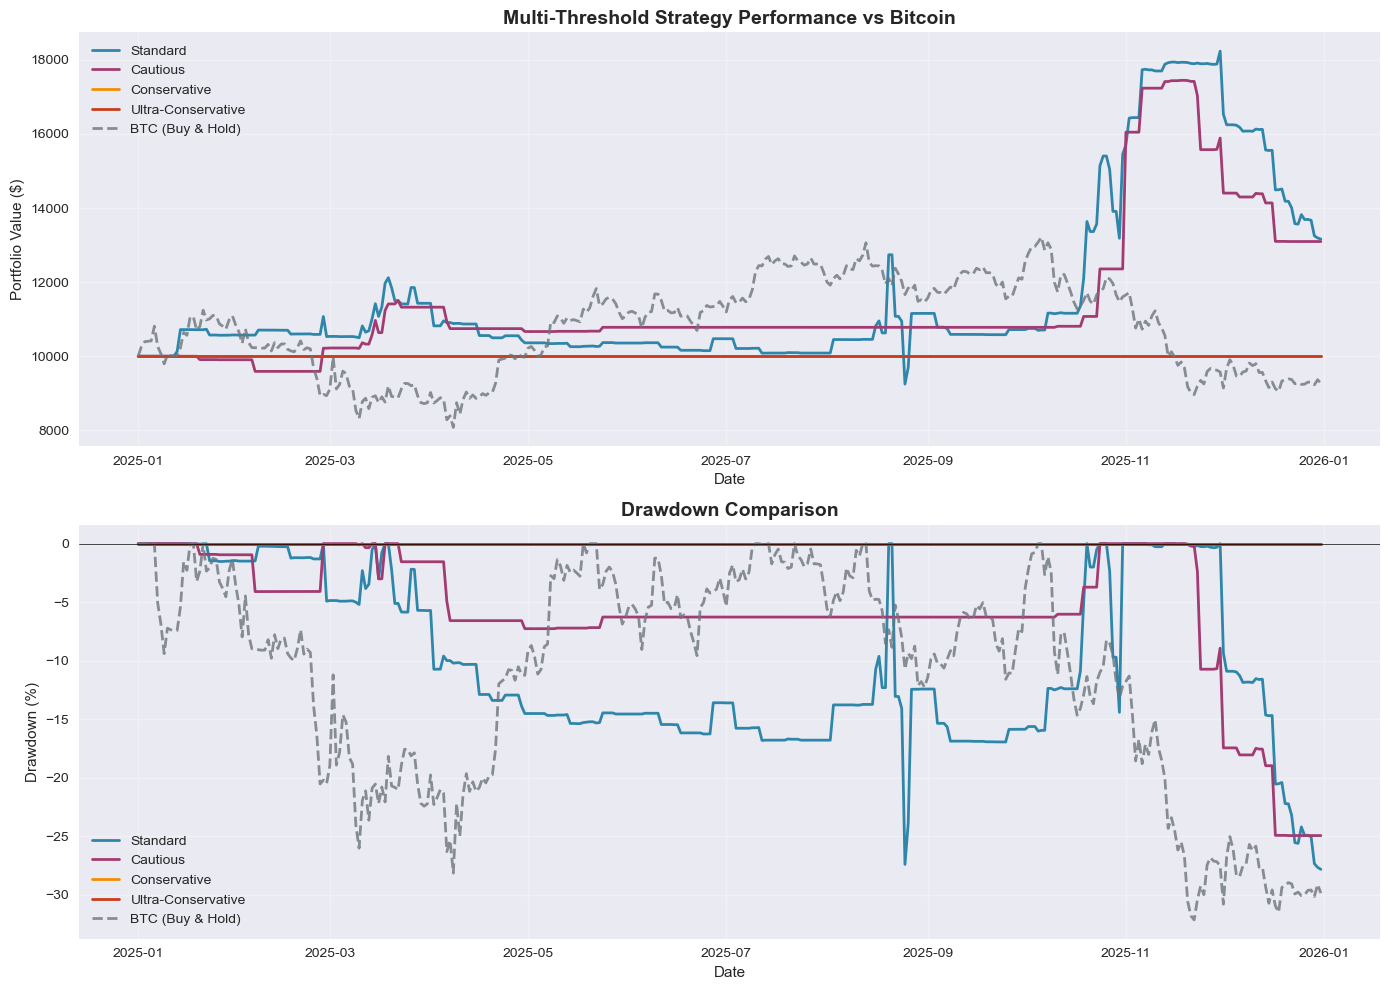

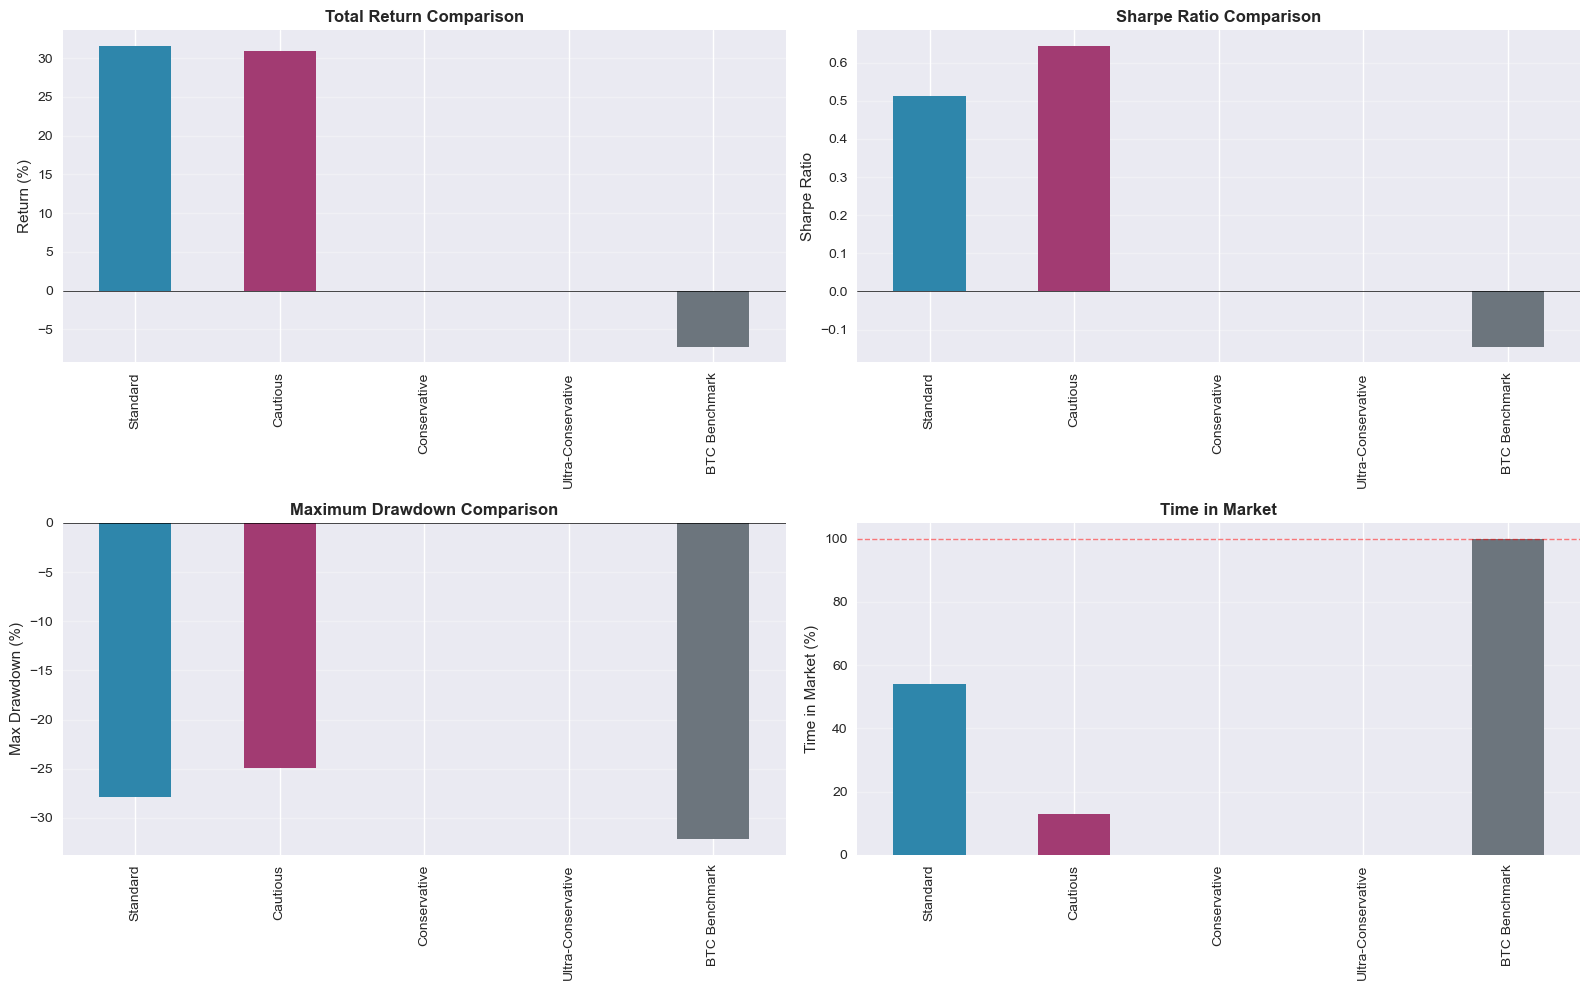

In [7]:
def main():
    print("="*70)
    print("INTEGRATED MULTI-THRESHOLD STRATEGY")
    print("AI + Graph Theory + Markowitz Optimization")
    print("="*70)
    
    file_path = 'dataset_2023_2025.xlsx'
    
    # Define thresholds
    THRESHOLDS = {
        'Standard': 0.50,
        'Cautious': 0.65,
        'Conservative': 0.80,
        'Ultra-Conservative': 0.90
    }
    
    # 1. Load Data
    data = load_data(file_path)
    if data is None:
        return
    
    # 2. Feature Engineering
    features, returns = engineer_enhanced_features(data)
    
    # 3. Train Enhanced AI Model
    rf_model, test_probs, X_test, y_test = train_enhanced_model(features)
    
    # 4. Analyze Confusion Matrices
    cm_results = analyze_confusion_matrices(y_test, test_probs, THRESHOLDS)
    print("\n--- AI MODEL RISK ANALYSIS ---")
    print(cm_results.to_string(index=False))
    
    # 5. Run Strategies for Each Threshold
    print("\n" + "="*70)
    print("BACKTESTING STRATEGIES")
    print("="*70)
    
    test_dates = X_test.index
    strategy_results = {}
    time_in_market = {}
    
    for name, threshold in THRESHOLDS.items():
        print(f"\n🔄 Running {name} Strategy (Threshold ≥ {threshold})...")
        result, tim = run_threshold_strategy(test_dates, returns, test_probs, 
                                             threshold=threshold)
        strategy_results[name] = result
        time_in_market[name] = tim
        print(f"   Time in Market: {tim:.1f}%")
    
    # 6. Benchmark: BTC Buy & Hold
    print("\n📈 Calculating BTC Benchmark...")
    btc_col = 'BTC-USD' if 'BTC-USD' in data.columns else data.columns[0]
    btc_series = data.loc[strategy_results['Standard'].index, btc_col]
    btc_norm = btc_series / btc_series.iloc[0] * 10000
    
    # 7. Calculate Metrics
    print("\n📊 Calculating Performance Metrics...")
    all_metrics = {}
    
    for name, series in strategy_results.items():
        all_metrics[name] = calculate_metrics(series)
        all_metrics[name]['Time in Market (%)'] = time_in_market[name]
    
    all_metrics['BTC Benchmark'] = calculate_metrics(btc_norm)
    all_metrics['BTC Benchmark']['Time in Market (%)'] = 100.0
    
    metrics_df = pd.DataFrame(all_metrics).T
    
    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON")
    print("="*70)
    print(metrics_df.round(2))
    
    # 8. Visualization
    print("\n🎨 Creating visualizations...")
    
    # Plot 1: Strategy Performance Comparison
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Portfolio Value Over Time
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6C757D']
    for i, (name, series) in enumerate(strategy_results.items()):
        ax1.plot(series, label=name, linewidth=2, color=colors[i])
    ax1.plot(btc_norm, label='BTC (Buy & Hold)', linestyle='--', 
            linewidth=2, color=colors[-1], alpha=0.8)
    
    ax1.set_title('Multi-Threshold Strategy Performance vs Bitcoin', 
                 fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Drawdown Comparison
    for i, (name, series) in enumerate(strategy_results.items()):
        drawdown = (series / series.cummax() - 1) * 100
        ax2.plot(drawdown, label=name, linewidth=2, color=colors[i])
    
    btc_dd = (btc_norm / btc_norm.cummax() - 1) * 100
    ax2.plot(btc_dd, label='BTC (Buy & Hold)', linestyle='--', 
            linewidth=2, color=colors[-1], alpha=0.8)
    
    ax2.set_title('Drawdown Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown (%)')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig('strategy_performance.png', dpi=300, bbox_inches='tight')
    print("✅ Performance chart saved!")
    
    # Plot 2: Metrics Comparison Bar Chart
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Total Return
    metrics_df['Total Return (%)'].plot(kind='bar', ax=axes[0, 0], color=colors)
    axes[0, 0].set_title('Total Return Comparison', fontweight='bold')
    axes[0, 0].set_ylabel('Return (%)')
    axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Sharpe Ratio
    metrics_df['Sharpe Ratio'].plot(kind='bar', ax=axes[0, 1], color=colors)
    axes[0, 1].set_title('Sharpe Ratio Comparison', fontweight='bold')
    axes[0, 1].set_ylabel('Sharpe Ratio')
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Max Drawdown
    metrics_df['Max Drawdown (%)'].plot(kind='bar', ax=axes[1, 0], color=colors)
    axes[1, 0].set_title('Maximum Drawdown Comparison', fontweight='bold')
    axes[1, 0].set_ylabel('Max Drawdown (%)')
    axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Time in Market
    metrics_df['Time in Market (%)'].plot(kind='bar', ax=axes[1, 1], color=colors)
    axes[1, 1].set_title('Time in Market', fontweight='bold')
    axes[1, 1].set_ylabel('Time in Market (%)')
    axes[1, 1].axhline(y=100, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Metrics chart saved!")
    
    # 9. Save Results to Excel
    print("\n💾 Saving results to Excel...")
    with pd.ExcelWriter('strategy_results.xlsx') as writer:
        metrics_df.to_excel(writer, sheet_name='Performance Metrics')
        cm_results.to_excel(writer, sheet_name='AI Risk Analysis', index=False)
        
        # Portfolio values over time
        portfolio_df = pd.DataFrame(strategy_results)
        portfolio_df['BTC_Benchmark'] = btc_norm
        portfolio_df.to_excel(writer, sheet_name='Portfolio Values')
    
    print("✅ Results saved to strategy_results.xlsx")
    
    print("\n" + "="*70)
    print("✅ ANALYSIS COMPLETE!")
    print("="*70)
    print("\nGenerated Files:")
    print("  1. strategy_performance.png - Performance & drawdown charts")
    print("  2. metrics_comparison.png - Bar charts of key metrics")
    print("  3. confusion_matrices.png - AI prediction analysis")
    print("  4. strategy_results.xlsx - Detailed results in Excel")
    print("\n" + "="*70)

if __name__ == "__main__":
    main()